<a href="https://colab.research.google.com/github/Hubaas/Deep-learning-using-Pytorch-using-Siamese-Networks-with-Triplet-Loss-Person-Re-Identification-/blob/main/Deep_Learning_with_PyTorch_Siamese_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install segmentation-models-pytorch
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install --upgrade opencv-contrib-python

  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-srzhl6lf
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-srzhl6lf
  Resolved https://github.com/albumentations-team/albumentations to commit 66212d77a44927a29d6a0e81621d3c27afbd929c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Download Full Dataset


In [ ]:
!git clone https://github.com/parth1620/Person-Re-Id-Dataset

fatal: destination path 'Person-Re-Id-Dataset' already exists and is not an empty directory.


# Imports

In [ ]:
import sys
sys.path.append('/content/Person-Re-Id-Dataset')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import timm

import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader

from skimage import io
from sklearn.model_selection import train_test_split

from tqdm import tqdm

# Configurations

In [ ]:
dat_dir = '/content/Person-Re-Id-Dataset/train/'
# '/content/Person-Re-Id-Dataset/train' for dat_dir original copy
csv_file = '/content/Person-Re-Id-Dataset/train.csv'

BATCH_SIZE =32
LR = 0.001
EPOCHS =15
DEVICES = 'cuda'

In [ ]:
df = pd.read_csv(csv_file)
df.head()

,Anchor,Negative,Positive
0,1420_c5s3_052165_01.jpg,1334_c6s3_061492_05.jpg,1420_c3s3_051678_01.jpg
1,1420_c3s3_061978_03.jpg,0234_c3s3_079494_02.jpg,1420_c6s3_085567_02.jpg
2,1420_c5s3_062565_05.jpg,0475_c2s1_122816_08.jpg,1420_c3s3_051653_01.jpg
3,1420_c6s3_085592_04.jpg,0662_c2s2_036662_05.jpg,1420_c1s6_013446_04.jpg
4,0663_c5s3_085987_03.jpg,1463_c2s3_098102_02.jpg,0663_c3s3_085544_06.jpg


In [ ]:
row= df.iloc[4]

a_img = io.imread(dat_dir + row.Anchor)
p_img = io.imread(dat_dir +'/'+ row.Positive)
n_img = io.imread(dat_dir + row.Negative)

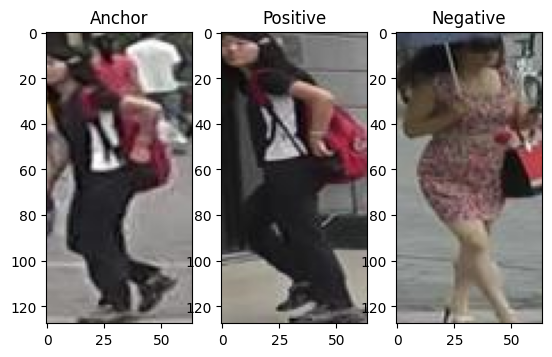

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(1,3)

ax1.set_title("Anchor")
ax1.imshow(a_img)

ax2.set_title("Positive")
ax2.imshow(p_img)

ax3.set_title("Negative")
ax3.imshow(n_img)

In [ ]:
train, test = train_test_split(df, test_size=0.2 , random_state=42)

# Create APN Dataset

In [ ]:
class APN_Dataset(Dataset):
  def __init__(self,df):
    self.df = df

  def __len__(self):
    return len(self.df)

  def __getitem__(self, indx) :
    row= self.df.iloc[indx]

    a_img = io.imread(dat_dir + row.Anchor)
    p_img = io.imread(dat_dir +'/'+ row.Positive)
    n_img = io.imread(dat_dir + row.Negative)

    a_img = torch.from_numpy(a_img).permute(2,0,1)/255.0
    p_img = torch.from_numpy(p_img).permute(2,0,1)/255.0
    n_img = torch.from_numpy(n_img).permute(2,0,1)/255.0

    return a_img, p_img, n_img

In [ ]:
trainset = APN_Dataset(train)
testset = APN_Dataset(test)

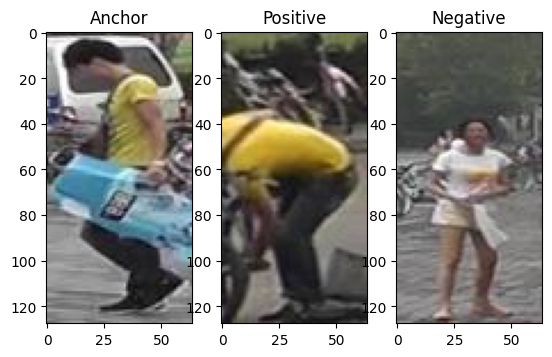

In [ ]:
indx = 40
A,P,N = trainset[indx]

f, (ax1, ax2, ax3) = plt.subplots(1,3)

ax1.set_title('Anchor')
ax1.imshow(A.numpy().transpose((1,2,0)), cmap = 'gray')

ax2.set_title('Positive')
ax2.imshow(P.numpy().transpose((1,2,0)), cmap = 'gray')

ax3.set_title('Negative')
ax3.imshow(N.numpy().transpose((1,2,0)), cmap = 'gray')

# Load Dataset into Batches

In [ ]:
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
validloader = DataLoader(testset, batch_size=BATCH_SIZE)

In [ ]:
print(f"No. of batches in trainloader : {len(trainloader)}")
print(f"No. of batches in validloader : {len(validloader)}")

No. of batches in trainloader : 100
No. of batches in validloader : 25


In [ ]:
for a,p,n in trainloader:
  print(f"Anchor shape : {a.shape}")
  print(f"Positive shape : {p.shape}")
  print(f"Negative shape : {n.shape}")
  break


Anchor shape : torch.Size([32, 3, 128, 64])
Positive shape : torch.Size([32, 3, 128, 64])
Negative shape : torch.Size([32, 3, 128, 64])


- 32: The batch size.
- 3: The number of color channels (for RGB images).
- 128: The height of the images in pixels.
- 64: The width of the images in pixels

# Create Model

In [ ]:
class APN_Model(nn.Module):
  def __init__(self, emb_size= 512):
    super(APN_Model, self).__init__()

    self.efficient= timm.create_model('efficientnet_b0', pretrained=True)
    self.efficient.classifier = nn.Linear(in_features=self.efficient.classifier.in_features, out_features=emb_size)

  def forward(self, images):
    embeddings = self.efficient(images)
    return embeddings

In [ ]:
model = APN_Model()
model.to(DEVICES);

# Create Train and Eval function

In [ ]:
def train_fn(model, dataLoader, optimizer, criterion):
  model.train() #ON dropout
  total_loss = 0.0

  for a,p,n in tqdm(dataLoader):
    a,p,n = a.to(DEVICES), p.to(DEVICES), n.to(DEVICES)

    a_emb = model(a)
    p_emb = model(p)
    n_emb = model(n)

    loss = criterion(a_emb, p_emb, n_emb)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  return total_loss/len(dataLoader)


In [ ]:
def eval_fn(model, dataloader, criterion):
  model.eval() #OFF dropout
  total_loss = 0.0

  with torch.no_grad():
    for a,p,n in tqdm(dataloader):
      a,p,n = a.to(DEVICES), p.to(DEVICES), n.to(DEVICES)
      a_emb = model(a)
      p_emb = model(p)
      n_emb = model(n)

      loss = criterion(a_emb, p_emb, n_emb)

      total_loss += loss.item()

  return total_loss/len(dataloader)

In [ ]:
criterion = nn.TripletMarginLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Create Training Loop

In [ ]:
best_vaild_loss = np.inf

for i in range(EPOCHS):
  train_loss = train_fn(model, trainloader, optimizer, criterion)
  valid_loss = eval_fn(model, validloader, criterion)

  if valid_loss < best_vaild_loss:
    torch.save(model.state_dict(), 'best_model.pt')
    best_vaild_loss = valid_loss
    print("SAVED WEIGHTS SUCCESS")

  print(f"EPOCH : {i+1}")
  print(f"Train Loss : {train_loss}")
  print(f"Valid Loss : {valid_loss}")

100%|██████████| 25/25 [00:02<00:00,  8.87it/s]


SAVED WEIGHTS SUCCESS
EPOCH : 1
Train Loss : 0.6106130902469158
Valid Loss : 0.44035046696662905


100%|██████████| 25/25 [00:02<00:00,  8.99it/s]


SAVED WEIGHTS SUCCESS
EPOCH : 2
Train Loss : 0.22064230889081954
Valid Loss : 0.29852663695812226


100%|██████████| 25/25 [00:02<00:00,  8.95it/s]


...

EPOCH : 13
Train Loss : 0.02024128459393978
Valid Loss : 0.17250628054141998


100%|██████████| 25/25 [00:02<00:00,  9.07it/s]


SAVED WEIGHTS SUCCESS
EPOCH : 14
Train Loss : 0.022188818156719206
Valid Loss : 0.12478352069854737


100%|██████████| 25/25 [00:02<00:00,  9.02it/s]

EPOCH : 15
Train Loss : 0.016966893151402474
Valid Loss : 0.15002652287483215


# Get Anchor Embeddings

In [ ]:
def get_encoding_csv(model, anc_img_names):
  anc_img_names_arr = np.array(anc_img_names)
  encodings =[]
  model.eval()
  with torch.no_grad():
    for i in tqdm(anc_img_names_arr):
      a = io.imread(dat_dir + i)
      a = torch.from_numpy(a).permute(2,0,1)/255.0
      a = a.unsqueeze(0).to(DEVICES)
      a_emb = model(a)
      encodings.append(a_emb.detach().cpu().numpy())

    encodings = np.array(encodings)
    encodings = pd.DataFrame(encodings.squeeze())
    df_emb = pd.concat([anc_img_names.reset_index(drop=True),encodings], axis=1)
    return df_emb

In [ ]:
model.load_state_dict(torch.load('best_model.pt'))
df_enc = get_encoding_csv(model, train['Anchor'])


100%|██████████| 3200/3200 [00:29<00:00, 108.28it/s]


In [ ]:
df_enc.to_csv('database.csv',index= False)
df_enc.head()

,Anchor,0,1,2,3,4,5,6,7,8,...,502,503,504,505,506,507,508,509,510,511
0,0326_c3s3_081044_04.jpg,0.596994,-0.786143,0.172475,-0.415145,0.443721,0.028629,0.134747,0.538382,-0.304451,...,0.192039,-0.245014,0.972544,0.280375,-0.305402,0.120537,-0.459557,-0.043841,-0.031531,0.269281
1,0724_c3s2_079903_02.jpg,-0.308259,-0.438736,0.351469,-0.565053,-0.597482,-0.318832,-0.105759,0.086477,-0.858440,...,0.416182,0.250283,0.203379,-0.751111,0.201592,-0.049946,0.256461,0.439065,0.520868,-0.361628
2,0809_c4s4_047835_02.jpg,-0.040861,-0.459356,0.508450,-0.973759,-0.504536,0.044742,0.156261,0.251495,-0.027531,...,-0.296422,-0.004212,-0.426140,-0.018543,-0.318929,-0.128425,0.010513,0.372317,0.501866,0.075445
3,0603_c6s2_011218_01.jpg,0.823442,-0.811401,0.211065,-0.609802,0.570727,0.017531,0.081400,0.538351,-0.063565,...,0.107143,-0.377366,0.817044,0.534451,-0.228990,0.267306,-0.462851,-0.106282,0.065030,0.151608
4,0594_c3s2_019937_04.jpg,0.090933,0.022905,-0.248264,0.044036,0.624251,0.047381,-0.313029,-0.130382,0.090050,...,-0.336488,0.177854,-0.930499,0.263877,0.590185,-0.120523,0.282361,0.439211,0.437014,-0.535227


# Inference

In [ ]:
def euclidean_dis(img_enc, anc_enc_arr):
  dist = np.sqrt(np.dot(img_enc - anc_enc_arr , (img_enc - anc_enc_arr).T))
  return dist

In [ ]:
idx = 202
img_name = df_enc['Anchor'].iloc[idx]
img_path = dat_dir + img_name

img = io.imread(img_path)
img = torch.from_numpy(img).permute(2,0,1)/255.0

model.eval()
with torch.no_grad():
  img = img.to(DEVICES)
  img_enc = model(img.unsqueeze(0))
  img_enc = img_enc.detach().cpu().numpy()
anc_enc_arr = df_enc.iloc[:, 1:].to_numpy()
anc_img_names = df_enc['Anchor']
distance = []

for i in range(anc_enc_arr.shape[0]):
  dist = euclidean_dis(img_enc, anc_enc_arr[i: i+1, :])
  distance = np.append(distance, dist)
closeset_idx = np.argsort(distance)

/usr/local/lib/python3.12/dist-packages/networkx/drawing/layout.py:982: RuntimeWarning: divide by zero encountered in divide
  costargs = (np, 1 / (dist_mtx + np.eye(dist_mtx.shape[0]) * 1e-3), meanwt, dim)


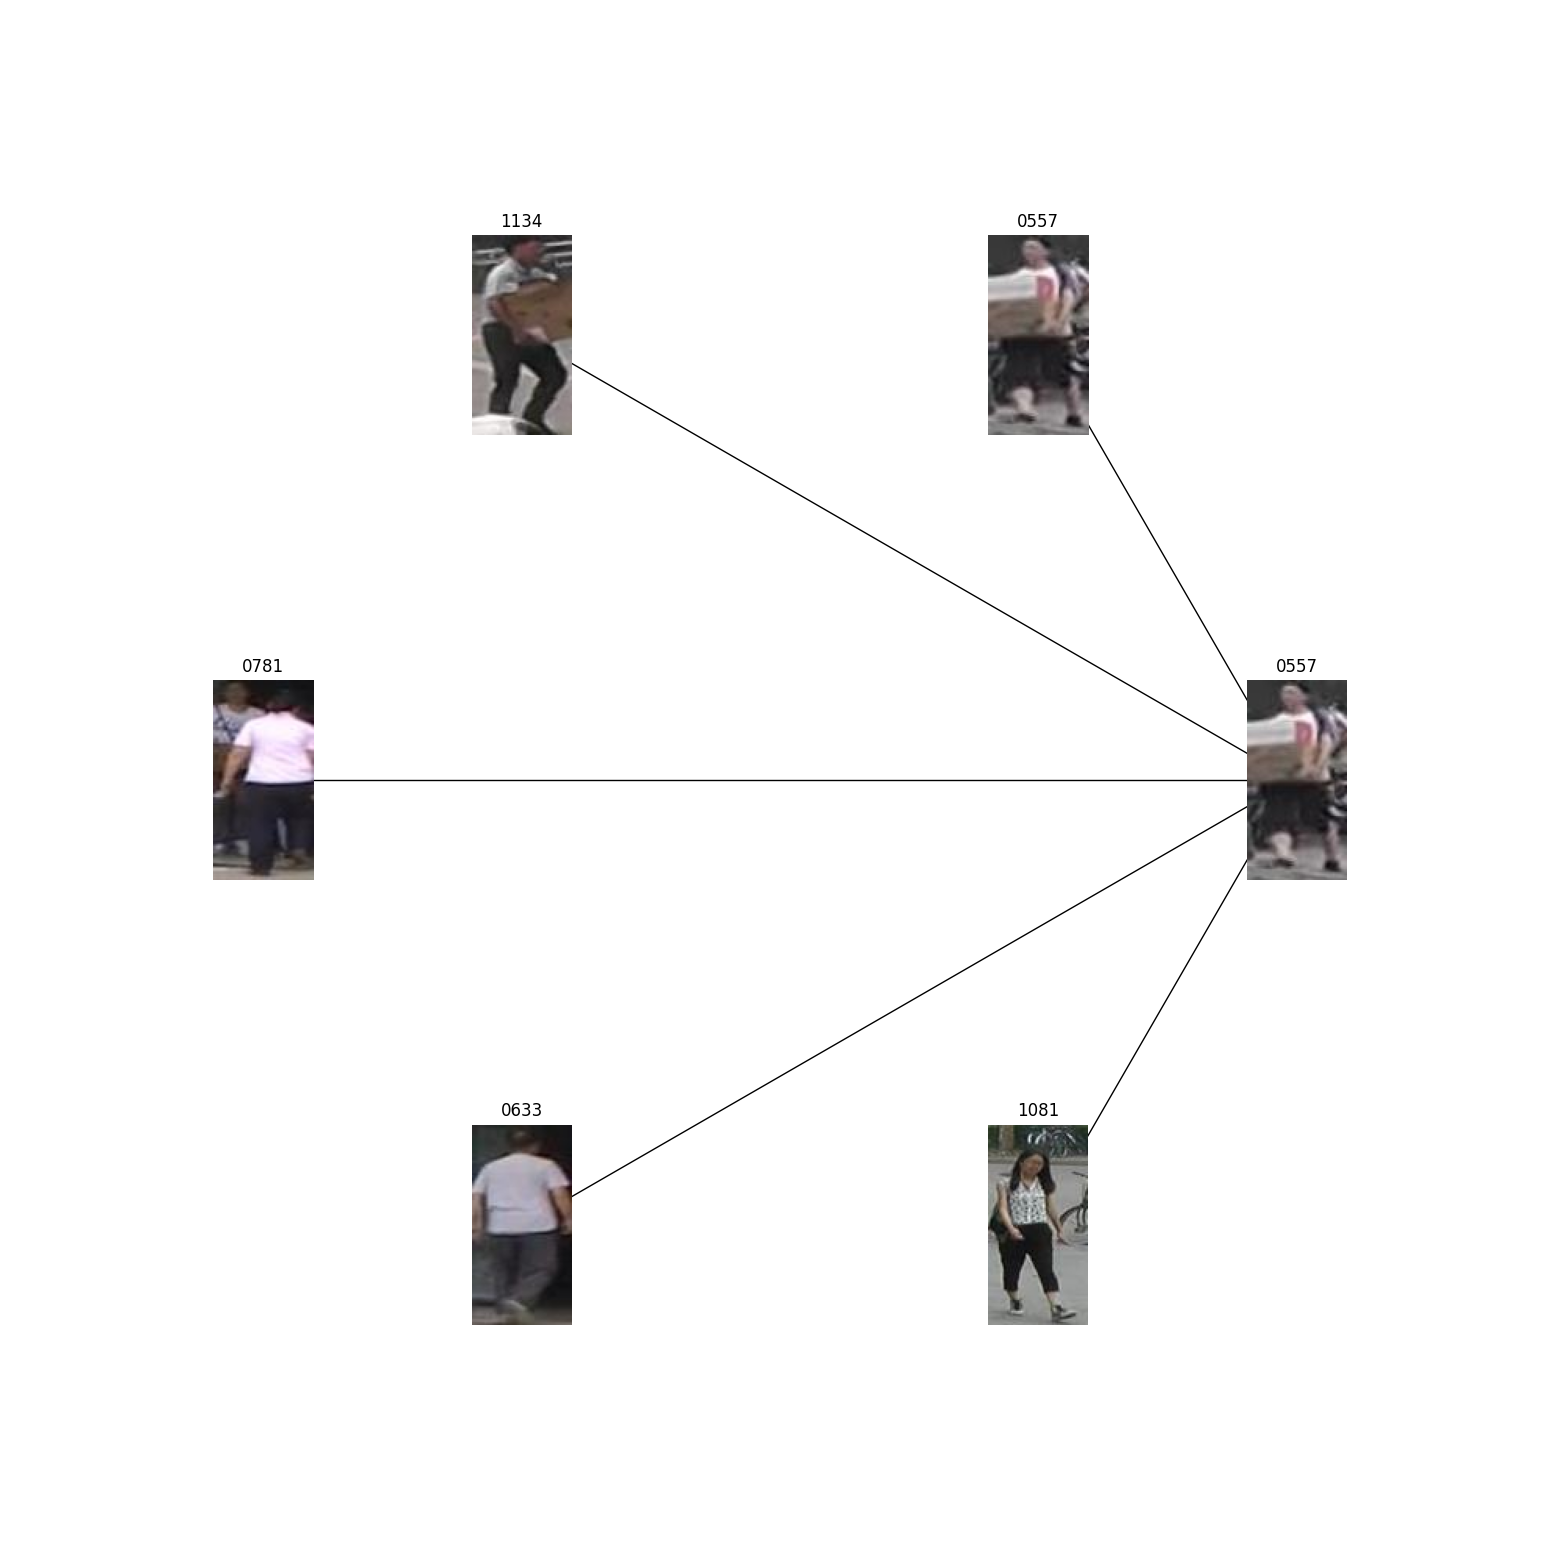

In [ ]:
from utils import plot_closest_imgs

plot_closest_imgs(anc_img_names, dat_dir , img, img_path, closeset_idx, distance, no_of_closest = 5);